[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd6-pm/new_nb_09_02_real_multiseed_equivariant_training.ipynb)

# new_nb_09_02. The real ladder: control and treatment across seeds

**Notebook 3 of 4, Idea 9 arm 2.**

**What the previous two notebooks settled.** `new_nb_09_00` fixed the question, the endpoint and the
decision rule before any data was seen. The endpoint is **rho**, the normalised mirror-consistency
residual, where **0 is exact mirror equivariance and the best value, 2 is unrelated, and 4 is complete
mirror blindness and the worst value**. The **anatomical mirror** `M` reflects the body and swaps left
and right landmark identities. Credit requires all three registered conditions to hold.

`new_nb_09_01` then established, on synthetic fixtures, three things this notebook depends on. The
head-only form of the equivariance term is an exact no-op. The registered `absolute` form has a
degenerate solution and satisfies itself by shrinking the readout instead of changing the encoder. And
the scale-invariant `parameter_free` form, which has no readout parameters at all, does move rho by more
than the control's trajectory noise. So this notebook uses `parameter_free`, and it refuses to run if
that mechanism gate has not passed, because a term that trains nothing would turn hours of compute into
a very expensive null.

**What this notebook answers.** Only this: what happens on real pose data, across seeds, when the
equivariance term is switched on and nothing else changes.

**What it deliberately does not do.** It does not judge. No condition of the credit rule is applied
here, no verdict is issued, and the trajectories are reported without being scored. The reason is stated
in full in section 5, and it is the same reason `new_nb_09_00` exists: a rule applied in the same
notebook that produced the numbers is a rule that can be adjusted while looking at them.

**What it produces.** Two checkpoints per seed with distinct fingerprints, a JSON per rung with its
full monitoring trajectory, a combined `idea9_arm2_ladder.json`, and a trajectory figure.

**What comes next.** `new_nb_09_03` reloads those checkpoints, recomputes every endpoint with one
instrument, and applies the rule mechanically.

**This notebook needs a GPU and real wall-clock time.** It writes a checkpoint and a JSON per rung, so
an interrupted run resumes at the next rung instead of starting over. On the run recorded here all six
rungs were already complete on disk and were resumed rather than retrained, which is why the ladder
reports finishing in 0.0 minutes.

**Research use only.** Folder labels are dataset annotations, not clinical diagnoses. Everything here is
transductive: the encoder trains on every sequence the endpoint is later measured on, on both rungs
equally.


## 1. Step 1 of 4. Why the seed has to be threaded, and what breaks if it is not

**What we are about to do.** Set up the environment and load every definition the ladder needs, having
first fixed one thing that notebook 04 gets away with and a multi-seed ladder cannot.

**The problem.** Notebook 04 fixes its seed in two places. The per-stage batch sampler is created as
`np.random.default_rng(42 + 1000 * stage["stage"])`, and the fingerprint payload records `"seed": 42`.
Both are literals.

**Why copying that verbatim would have been quietly fatal.** Every seed would draw the same batch order
and write the same fingerprint, so five nominal seeds would have produced five identical runs. The seed
spread across those runs would then come out as exactly zero. And the seed spread is not an incidental
diagnostic here: it is the yardstick condition 1 of the credit rule is measured against. With a spread of
zero, *any* difference at all between control and treatment would appear to clear it, and the experiment
would have manufactured a pass out of a bug.

**What this notebook does instead.** One seed is threaded through every source of randomness: model
initialisation, the batch sampler, and the mask sampler. `seed`, `equiv_weight`, `equiv_on` and the
equivariance variant also join the fingerprint payload, so each rung has its own identity and no rung can
be mistaken for the published baseline lineage. Section 4 checks that this actually worked, by asserting
that all six fingerprints are distinct.

**One deliberate deviation from notebook 04, stated up front.** Notebook 04 computes its representation
diagnostics after every epoch. Doing that here would roughly double the cost of the ladder for monitoring
alone, so the diagnostics and rho are measured every twenty-fifth epoch and at every stage boundary. The
optimiser path is untouched, so this changes what is *observed*, not what is *trained*.

**What to look at in the next two cells' output.** Very little, because nothing is measured yet. Confirm
that `mode` resolves to the real artifact tree, that the output directory ends in `idea9_arm2`, and that
the definitions cell reports a GPU device rather than `cpu`. On CPU this ladder takes many hours.


In [1]:
from pathlib import Path
import os, sys, json, math, hashlib, copy, time, warnings

import numpy as np
import pandas as pd

RANDOM_SEED = 42


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6-pm"
try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

TRUTHY = {"1", "true", "yes", "on"}
REQUESTED_MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
INCLUDE_AUGMENTED = os.getenv("SJEPA_INCLUDE_AUGMENTED_NORMAL", "0").strip().lower() in TRUTHY
ARTIFACT_ROOT = Path(os.getenv("GAVD_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")).expanduser()
CACHE_DIR = Path(os.getenv("GAVD_CACHE_DIR", TUTORIAL_DIR / "work" / "cache")).expanduser()
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]

# The six authorised left/right pairs the head, the signed target, and rho are all built from.
LEFT_RIGHT_PAIRS = [(11, 12), (23, 24), (25, 26), (27, 28), (29, 30), (31, 32)]
# The full 16-pair anatomical mirror, matching notebook 04's geometric_view flip.
FULL_MIRROR_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10),
    (11, 12), (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]

# Arm-2 output lives in its own directory. Nothing here ever writes a baseline artifact name.
ARM2_DIR_NAME = "idea9_arm2"
BASELINE_CHECKPOINT_NAME = (
    "sjepa_curriculum_final_augmented.pt" if INCLUDE_AUGMENTED else "sjepa_curriculum_final.pt"
)


def artifact_dir_for(mode):
    return ARTIFACT_ROOT / mode


MODE = REQUESTED_MODE
if MODE != "real":
    raise RuntimeError(
        "This notebook is the REAL ladder. Set GAVD_MODE=real in experiments/sjepa/gavd6-pm/.env and "
        "restart the kernel. Use new_nb_09_01 for the runnable synthetic mechanism checks.")
ARTIFACT_DIR = artifact_dir_for(MODE)
ARM2_DIR = ARTIFACT_DIR / ARM2_DIR_NAME
ARM2_DIR.mkdir(parents=True, exist_ok=True)

CONTRACT_PATH = ARM2_DIR / "idea9_arm2_contract.json"
MECHANISM_PATH = ARM2_DIR / "idea9_arm2_mechanism_validation.json"
if not CONTRACT_PATH.is_file():
    raise FileNotFoundError(f"Run new_nb_09_00 first: {CONTRACT_PATH} is missing")
if not MECHANISM_PATH.is_file():
    raise FileNotFoundError(f"Run new_nb_09_01 first: {MECHANISM_PATH} is missing")
CONTRACT = json.loads(CONTRACT_PATH.read_text())
MECHANISM = json.loads(MECHANISM_PATH.read_text())
if MECHANISM.get("gate_for_the_real_ladder") != "PASSED":
    raise RuntimeError(
        "The mechanism gate in new_nb_09_01 did not pass. A term that trains nothing would make this "
        "ladder an expensive null. Fix the mechanism first.")
EQUIV_VARIANT = MECHANISM["selected_variant_for_the_real_ladder"]

print(f"mode                : {MODE}")
print(f"output directory    : {ARM2_DIR}")
print(f"mechanism gate      : {MECHANISM['gate_for_the_real_ladder']}")
print(f"equivariance variant: {EQUIV_VARIANT}")
print(f"baseline reference  : {CONTRACT['contract']['baseline_fingerprint'][:16]} "
      f"({CONTRACT['contract']['baseline_checkpoint']})")

mode                : real
output directory    : /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/idea9_arm2
mechanism gate      : PASSED
equivariance variant: parameter_free
baseline reference  : ea59fea055f0230b (sjepa_curriculum_final_augmented.pt)


In [2]:
import torch
from torch import nn
from torch.nn import functional as F


class SkeletonPatchEncoder(nn.Module):
    def __init__(self, frames=64, joints=33, coordinate_dim=3, segment_length=4,
                 embed_dim=64, depth=2, heads=4, dropout=0.0):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames, self.joints = frames, joints
        self.coordinate_dim, self.segment_length = coordinate_dim, segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=heads, dim_feedforward=embed_dim * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(batch, self.segments, self.segment_length, joints, channels)
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return tokens + self.time_pos[None, :, None, :] + self.joint_pos[None, None, :, :]

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept = keep_mask.sum(dim=1)
            if not torch.equal(kept, kept[:1].expand_as(kept)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(self, segments, joints, encoder_dim=64, predictor_dim=64,
                 depth=2, heads=4, dropout=0.0):
        super().__init__()
        self.segments, self.joints = segments, joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim, nhead=heads, dim_feedforward=predictor_dim * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(batch, self.segments * self.joints, -1).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (self.time_pos[:, None, :] + self.joint_pos[None, :, :]).reshape(
            1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(self, frames=64, joints=33, coordinate_dim=3, segment_length=4,
                 embed_dim=64, encoder_depth=2, predictor_depth=2, heads=4):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length, embed_dim, encoder_depth, heads)
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments, joints, embed_dim, embed_dim, predictor_depth, heads)
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(len(target), -1, all_targets.shape[-1])
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
                self.target_encoder.parameters(), self.view_encoder.parameters()):
            target_parameter.mul_(momentum).add_(view_parameter, alpha=1.0 - momentum)

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        self.target_center.mul_(beta).add_(targets.mean(dim=(0, 1)), alpha=1.0 - beta)


def sjepa_cross_entropy(predicted, targets, center,
                        predictor_temperature=0.10, target_temperature=0.06):
    target_prob = torch.softmax(
        (targets - center[None, None, :]) / target_temperature, dim=-1).detach()
    prediction_log_prob = torch.log_softmax(predicted / predictor_temperature, dim=-1)
    return -(target_prob * prediction_log_prob).sum(dim=-1).mean()


def cosine_ema(step, total_steps, start=0.996, end=1.0):
    progress = min(max(step / max(total_steps - 1, 1), 0.0), 1.0)
    return end - (end - start) * (math.cos(math.pi * progress) + 1.0) / 2.0

def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (np.arange(1, gap + 1, dtype=np.float32) / (gap + 1))[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction)
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    both = left_ok & right_ok
    pelvis[both] = 0.5 * (left_hip[both] + right_hip[both])
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0)
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack([np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])], axis=1)
    return resized.reshape(frames, *array.shape[1:])


def prepare_sequence(raw_sequence, frames):
    """raw_sequence: [T, 33, 4] -> (xyz [frames, 33, 3] float32, valid [frames, 33] bool)."""
    interpolated, valid = interpolate_low_visibility(raw_sequence)
    scaled = center_and_scale(interpolated)
    xyz = temporal_resize(scaled[..., :3], frames)
    valid_resized = temporal_resize(valid.astype(np.float32), frames) > 0.5
    return xyz.astype(np.float32), valid_resized


def anatomical_mirror_raw(coords, pairs=FULL_MIRROR_PAIRS):
    """Mirror the RAW [T, 33, 4] column so the SAME preprocessing can be re-run on the reflection."""
    mirrored = np.asarray(coords, dtype=np.float32).copy()
    mirrored[:, :, 0] = -mirrored[:, :, 0]
    for left, right in pairs:
        mirrored[:, [left, right], :] = mirrored[:, [right, left], :]
    return mirrored


def signed_left_minus_right(coords):
    """Item 05's frozen target: signed per-side excursion, left minus right, on preprocessed coords."""
    coords = np.asarray(coords, dtype=np.float64)[..., :3]
    total = 0.0
    for left, right in LEFT_RIGHT_PAIRS:
        total += coords[:, left, :].std(axis=0).sum() - coords[:, right, :].std(axis=0).sum()
    return float(total)

def anatomical_mirror_coords(coords):
    """Reflect the RAW skeleton: negate the sideways x coordinate and swap each left/right landmark.

    coords: [B, FRAMES, 33, 3] tensor. Differentiable passthrough, so gradients flow through the mirror.
    """
    mirrored = coords.clone()
    mirrored[..., 0] = -mirrored[..., 0]
    index = list(range(33))
    for left, right in FULL_MIRROR_PAIRS:
        index[left], index[right] = right, left
    return mirrored[:, :, index, :]


class AntisymmetricHead(nn.Module):
    """s = sum over pairs of ( f(L) - f(R) ), with f shared across joints and sides.

    Difference only, so the head negates under a swap of its own inputs by construction. In Arm 2 the
    head's parameters are trainable and join the optimiser, so L_equiv can shape the encoder and the
    head together.
    """

    def __init__(self, embed_dim, out_dim=4, hidden=32, pairs=LEFT_RIGHT_PAIRS):
        super().__init__()
        self.pairs = list(pairs)
        self.f = nn.Sequential(nn.Linear(embed_dim, hidden), nn.GELU(), nn.Linear(hidden, out_dim))

    def per_joint_feature(self, tokens):
        return tokens.mean(dim=1)

    def s_from_perjoint(self, per_joint):
        out = 0.0
        for left, right in self.pairs:
            out = out + (self.f(per_joint[:, left, :]) - self.f(per_joint[:, right, :]))
        return out

    def forward(self, tokens):
        return self.s_from_perjoint(self.per_joint_feature(tokens))

    def swapped(self, tokens):
        """Wiring self-check only. Returns -forward(tokens) by construction, so it trains nothing."""
        per_joint = self.per_joint_feature(tokens)
        swapped = per_joint.clone()
        for left, right in self.pairs:
            swapped[:, left, :] = per_joint[:, right, :]
            swapped[:, right, :] = per_joint[:, left, :]
        return self.s_from_perjoint(swapped)


def encoder_tokens_for_head(view_encoder, coords, segments, joints, embed_dim):
    return view_encoder(coords).reshape(len(coords), segments, joints, embed_dim)


def mirror_pair_signals(readout, view_encoder, coords, segments, embed_dim, joints=33):
    """Return ( s(enc(x)), s(enc(Mx)) ) with M the anatomical mirror on the RAW skeleton.

    The mirror is applied to raw coordinates and BOTH versions are run through the view encoder. A
    head-only token swap would be identically zero for every input and every parameter, so it would train
    nothing at all. Going through the encoder makes the residual a genuine constraint on encoder weights.
    """
    tokens = encoder_tokens_for_head(view_encoder, coords, segments, joints, embed_dim)
    tokens_mirrored = encoder_tokens_for_head(
        view_encoder, anatomical_mirror_coords(coords), segments, joints, embed_dim)
    return readout(tokens), readout(tokens_mirrored)


def equivariance_loss_absolute(head, view_encoder, coords, segments, embed_dim, joints=33):
    """nb_09b's term exactly as written: L = mean( ( s(enc(Mx)) + s(enc(x)) )^2 ).

    This has a degenerate solution. Because the head is trainable and shares the objective, the cheapest
    way to shrink the squared residual is to shrink s itself, which costs the encoder nothing. Notebook 01
    measures that collapse happening, which is why this variant is kept only as the documented baseline
    for comparison and is not used for the real ladder.
    """
    s, s_mirrored = mirror_pair_signals(head, view_encoder, coords, segments, embed_dim, joints)
    return ((s_mirrored + s) ** 2).mean()


def equivariance_loss_normalized(head, view_encoder, coords, segments, embed_dim,
                                 joints=33, eps=1e-6):
    """The scale-invariant repair, with the trainable head retained.

    L = mean_seq [ ||s(enc(Mx)) + s(enc(x))||^2 / ( 0.5 * (||s(enc(x))||^2 + ||s(enc(Mx))||^2) + eps ) ]

    Dividing by the signal's own magnitude removes the shrink-the-head escape route: scaling s by any
    constant leaves the ratio unchanged, so the only way down is for the encoder to actually represent the
    mirrored body as the sign flip of the original. Still label-free.
    """
    s, s_mirrored = mirror_pair_signals(head, view_encoder, coords, segments, embed_dim, joints)
    numerator = ((s_mirrored + s) ** 2).sum(dim=1)
    denominator = 0.5 * ((s ** 2).sum(dim=1) + (s_mirrored ** 2).sum(dim=1))
    return (numerator / (denominator + eps)).mean()


def equivariance_loss_parameter_free(view_encoder, coords, segments, embed_dim,
                                     joints=33, eps=1e-6):
    """The same scale-invariant residual with the head replaced by the identity feature map.

    This removes the head from the objective entirely, so there are no readout parameters that could be
    tuned to flatter the term. Its aggregation is a mean of per-sequence ratios, whereas the reported
    endpoint rho is a ratio of sums over the whole cohort, so the two are related but not identical.
    """
    s, s_mirrored = mirror_pair_signals(
        antisymmetric_contraction, view_encoder, coords, segments, embed_dim, joints)
    numerator = ((s_mirrored + s) ** 2).sum(dim=1)
    denominator = 0.5 * ((s ** 2).sum(dim=1) + (s_mirrored ** 2).sum(dim=1))
    return (numerator / (denominator + eps)).mean()


EQUIVARIANCE_VARIANTS = {
    "absolute": "nb_09b as written; has a shrink-the-head degenerate solution",
    "normalized": "scale-invariant, trainable head retained",
    "parameter_free": "scale-invariant, head removed from the objective",
}


def equivariance_term(variant, head, view_encoder, coords, segments, embed_dim, joints=33):
    """Dispatch to one equivariance variant, so a rung records which form it optimised."""
    if variant == "absolute":
        return equivariance_loss_absolute(head, view_encoder, coords, segments, embed_dim, joints)
    if variant == "normalized":
        return equivariance_loss_normalized(head, view_encoder, coords, segments, embed_dim, joints)
    if variant == "parameter_free":
        return equivariance_loss_parameter_free(view_encoder, coords, segments, embed_dim, joints)
    raise ValueError(f"unknown equivariance variant {variant!r}")


# --- the pre-registered PRIMARY endpoint: parameter-free, label-free, no fitting ----------------
def antisymmetric_contraction(tokens):
    """T(tokens) = sum over authorised pairs of ( tok_L - tok_R ) after a per-joint time mean.

    This is the AntisymmetricHead with f set to the identity, so it has no parameters at all. That makes
    it comparable across checkpoints without fitting anything and without a label.
    tokens: [B, SEGMENTS, 33, D] -> [B, D]
    """
    per_joint = tokens.mean(dim=1)
    out = 0.0
    for left, right in LEFT_RIGHT_PAIRS:
        out = out + (per_joint[:, left, :] - per_joint[:, right, :])
    return out


@torch.no_grad()
def mirror_residual_terms(encoder, xyz, segments, embed_dim, device, batch_size=16):
    """Per-sequence numerator and denominator of the normalised mirror-consistency residual rho.

    rho = mean_seq || T(enc(Mx)) + T(enc(x)) ||^2
        / mean_seq ( 0.5 * ( || T(enc(x)) ||^2 + || T(enc(Mx)) ||^2 ) )

    Scale, which is what makes rho readable without a target: rho = 0 means the encoder represents the
    mirrored body as the exact sign flip of the original along this axis, rho = 2 means the two are
    unrelated, and rho = 4 means the encoder is fully symmetric and cannot tell a body from its mirror.
    Lower is more mirror-honest. Returned per sequence so results can be aggregated by source video.
    """
    numerators, denominators = [], []
    for start in range(0, len(xyz), batch_size):
        chunk = torch.tensor(xyz[start:start + batch_size], dtype=torch.float32, device=device)
        tokens = encoder(chunk).reshape(len(chunk), segments, 33, embed_dim)
        tokens_mirrored = encoder(anatomical_mirror_coords(chunk)).reshape(
            len(chunk), segments, 33, embed_dim)
        s = antisymmetric_contraction(tokens)
        s_mirrored = antisymmetric_contraction(tokens_mirrored)
        numerators.append(((s_mirrored + s) ** 2).sum(dim=1).cpu().numpy())
        denominators.append((0.5 * ((s ** 2).sum(dim=1) + (s_mirrored ** 2).sum(dim=1))).cpu().numpy())
    return np.concatenate(numerators), np.concatenate(denominators)


def rho_from_terms(numerators, denominators):
    total = float(np.sum(denominators))
    if total <= 0:
        return float("nan")
    return float(np.sum(numerators) / total)


@torch.no_grad()
def head_signal_scale(head, encoder, xyz, segments, embed_dim, device, batch_size=16):
    """Mean ||s|| over the cohort. Evidence for or against the shrink-the-head degenerate solution."""
    norms = []
    for start in range(0, len(xyz), batch_size):
        chunk = torch.tensor(xyz[start:start + batch_size], dtype=torch.float32, device=device)
        tokens = encoder(chunk).reshape(len(chunk), segments, 33, embed_dim)
        norms.append(head(tokens).norm(dim=1).cpu().numpy())
    return float(np.mean(np.concatenate(norms)))

def uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=None):
    """Sample eligible joint-time tokens uniformly, with no motion score. Verbatim from notebook 04."""
    valid_patch = np.asarray(valid_patch, dtype=bool)
    if valid_patch.ndim != 3 or valid_patch.shape[2] != 33:
        raise ValueError(f"Expected [B, S, 33], received {valid_patch.shape}")
    if not 0.0 < mask_fraction < 1.0:
        raise ValueError("mask_fraction must be between 0 and 1")
    rng = np.random.default_rng(seed)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.reshape(len(eligible), -1).sum(axis=1)
    if np.any(counts < 2):
        raise ValueError("Each sample needs at least two valid eligible tokens")
    n_mask = max(1, int(np.floor(counts.min() * mask_fraction)))
    n_mask = min(n_mask, int(counts.min()) - 1)
    mask = np.zeros_like(eligible)
    for index in range(len(mask)):
        candidates = np.flatnonzero(eligible[index].reshape(-1))
        mask[index].reshape(-1)[rng.choice(candidates, size=n_mask, replace=False)] = True
    forbidden = sorted(set(range(33)).difference(MASK_KEYPOINTS))
    if mask[:, :, forbidden].any():
        raise AssertionError("A forbidden keypoint entered the target mask")
    return mask


def geometric_view(x, max_degrees=8.0, translate=0.03, flip_probability=0.0):
    """Notebook 04's augmentation: y-axis rotation mixing x and z, plus a small translation.

    flip_probability stays 0.0 exactly as in notebook 04. Turning the flip on would put mirrored bodies
    into the JEPA branch itself, which would confound the equivariance term with a data augmentation.
    """
    view = x.clone()
    present = view.abs().sum(dim=-1) > 1e-8
    batch = len(view)
    angles = (torch.rand(batch, device=x.device) * 2.0 - 1.0) * math.radians(max_degrees)
    cosine, sine = torch.cos(angles), torch.sin(angles)
    original_x, original_z = view[..., 0].clone(), view[..., 2].clone()
    view[..., 0] = cosine[:, None, None] * original_x + sine[:, None, None] * original_z
    view[..., 2] = -sine[:, None, None] * original_x + cosine[:, None, None] * original_z
    view[..., :2] += (torch.rand(batch, 1, 1, 2, device=x.device) * 2.0 - 1.0) * translate
    if flip_probability > 0:
        raise ValueError("The flip augmentation must stay off; it would confound L_equiv")
    return view.masked_fill(~present[..., None], 0.0)


def authorized_pool(tokens, valid_patch):
    """Pool only valid tokens from the 12 authorised landmarks. Verbatim from notebook 04."""
    batch, segments, _, dimension = tokens.shape
    selected = tokens[:, :, MASK_KEYPOINTS].reshape(batch, -1, dimension)
    weights = valid_patch[:, :, MASK_KEYPOINTS].reshape(batch, -1).to(tokens.dtype)
    denominator = weights.sum(dim=1, keepdim=True).clamp_min(1.0)
    return (selected * weights.unsqueeze(-1)).sum(dim=1) / denominator


def off_diagonal(matrix):
    n, m = matrix.shape
    if n != m:
        raise ValueError("Covariance matrix must be square")
    return matrix.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()


def vicreg_terms(first, second, gamma=1.0, eps=1e-4):
    """VICReg invariance, variance hinge, and off-diagonal covariance. Verbatim from notebook 04."""
    invariance = F.mse_loss(first, second)
    first_std = torch.sqrt(first.var(dim=0, unbiased=False) + eps)
    second_std = torch.sqrt(second.var(dim=0, unbiased=False) + eps)
    variance = 0.5 * (F.relu(gamma - first_std).mean() + F.relu(gamma - second_std).mean())
    first_centered = first - first.mean(dim=0)
    second_centered = second - second.mean(dim=0)
    denominator = max(len(first) - 1, 1)
    first_cov = first_centered.T @ first_centered / denominator
    second_cov = second_centered.T @ second_centered / denominator
    covariance = (off_diagonal(first_cov).square().sum()
                  + off_diagonal(second_cov).square().sum()) / (2.0 * first.shape[1])
    return 25.0 * invariance + 25.0 * variance + covariance, invariance, variance, covariance


def condition_group_terms(representations, condition_ids, margin=1.0):
    """Bounded compactness and centroid separation on unit vectors. Verbatim from notebook 04."""
    unique = torch.unique(condition_ids)
    zero = representations.sum() * 0.0
    if len(unique) < 2:
        return zero, zero, torch.tensor(float("nan"), device=representations.device)
    normalized = F.normalize(representations, dim=1)
    centroids = torch.stack([
        F.normalize(normalized[condition_ids == value].mean(dim=0), dim=0) for value in unique])
    compactness = torch.stack([
        (normalized[condition_ids == value] - centroids[index]).square().sum(dim=1).mean()
        for index, value in enumerate(unique)]).mean()
    pairwise = (centroids[:, None] - centroids[None, :]).square().sum(dim=-1).clamp_min(1e-12).sqrt()
    upper = torch.triu(torch.ones_like(pairwise, dtype=torch.bool), diagonal=1)
    distances = pairwise[upper]
    return compactness, F.relu(margin - distances).square().mean(), distances.min()


def balanced_epoch_batches(data_by_condition, active_conditions, per_condition, rng):
    """Exhaustive, class-balanced replay batches for one epoch. Verbatim from notebook 04."""
    lengths = {c: len(data_by_condition[c]["xyz"]) for c in active_conditions}
    if min(lengths.values()) < 1:
        raise ValueError(f"Empty curriculum condition: {lengths}")
    steps = max(1, int(np.ceil(max(lengths.values()) / per_condition)))
    required = steps * per_condition
    orders = {}
    for condition in active_conditions:
        pieces = []
        while sum(len(piece) for piece in pieces) < required:
            pieces.append(rng.permutation(lengths[condition]))
        orders[condition] = np.concatenate(pieces)[:required]
    for step in range(steps):
        xyz_parts, valid_parts, label_parts = [], [], []
        for label, condition in enumerate(active_conditions):
            take = orders[condition][step * per_condition:(step + 1) * per_condition]
            xyz_parts.append(data_by_condition[condition]["xyz"][take])
            valid_parts.append(data_by_condition[condition]["valid"][take])
            label_parts.extend([label] * per_condition)
        permutation = rng.permutation(len(label_parts))
        yield (np.concatenate(xyz_parts)[permutation],
               np.concatenate(valid_parts)[permutation],
               np.asarray(label_parts, dtype=np.int64)[permutation])


class VICRegProjector(nn.Module):
    def __init__(self, dimension):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dimension, dimension), nn.GELU(),
                                 nn.Linear(dimension, dimension))

    def forward(self, x):
        return self.net(x)


def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

POSE_CACHE_CONTRACT = json.loads((TUTORIAL_DIR / "pose_cache_contract.json").read_text())
COMPATIBLE_EXTRACTION_VERSIONS = frozenset(POSE_CACHE_CONTRACT["compatible_extraction_versions"])
COHORT_ROOT = PROJECT_ROOT / "data" / "gavd"
EXPECTED_SEQUENCE_COUNTS = {"normal": 12, "parkinsons": 9, "stroke": 12,
                            "myopathic": 47, "cerebralpalsy": 16}
EXPECTED_SEQUENCE_IDS = {
    condition: {path.stem for path in (COHORT_ROOT / condition).glob("*.csv")}
    for condition in CONDITIONS
}
MIN_AUGMENTED_NEURO_OBSERVED = 0.45


def canonical_pose_records(pose_dir, conditions=CONDITIONS):
    """Load the locked canonical pose cache with the same identity checks notebook 04 applies."""
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        available = {path.stem: path for path in folder.glob("*.npz")}
        expected = EXPECTED_SEQUENCE_IDS[condition]
        if set(available) != expected:
            raise ValueError(
                f"Canonical {condition} pose cache does not match the locked cohort at {folder}: "
                f"expected {len(expected)}, found {len(available)}")
        for sequence_id in sorted(expected):
            data = np.load(available[sequence_id], allow_pickle=False)
            version = str(data["extraction_version"].item())
            if version not in COMPATIBLE_EXTRACTION_VERSIONS:
                raise ValueError(f"Unsupported extraction version {version} in {available[sequence_id]}")
            sequence = data["sequence"].astype(np.float32)
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape {sequence.shape}")
            records.append({
                "condition": condition,
                "sequence_id": str(data["sequence_id"].item()),
                "video_id": str(data["video_id"].item()),
                "raw": sequence,
                "cohort": "canonical",
            })
    return records


def augmented_normal_records(artifact_dir):
    """Load the opt-in augmentation-normal cohort through its selection report, as notebook 04 does."""
    if not INCLUDE_AUGMENTED:
        return []
    folder = artifact_dir / "poses_augmented" / "normal"
    report_path = artifact_dir / "augmented_pose_extraction_report.csv"
    if not folder.exists() or not report_path.is_file():
        raise FileNotFoundError(
            f"SJEPA_INCLUDE_AUGMENTED_NORMAL is enabled but {folder} or {report_path} is missing. "
            "Run notes/migrate_augmented_pose_artifacts.py, or notes/annotate_normal_clips.py then "
            "notes/extract_augmented_poses.py.")
    report = pd.read_csv(report_path)
    candidates = report[~report["status"].astype(str).str.startswith("error")].copy()
    accepted = pd.to_numeric(candidates["neuro_observed"], errors="coerce") >= MIN_AUGMENTED_NEURO_OBSERVED
    selected = set(candidates.loc[accepted, "sequence_id"].astype(str))
    available = {path.stem: path for path in folder.glob("*.npz")}
    if set(available) != selected:
        raise ValueError("Augmented pose cache does not match its selection report")
    records = []
    for sequence_id in sorted(selected):
        data = np.load(available[sequence_id], allow_pickle=False)
        records.append({
            "condition": "normal",
            "sequence_id": str(data["sequence_id"].item()),
            "video_id": str(data["video_id"].item()),
            "raw": data["sequence"].astype(np.float32),
            "cohort": "augmented_normal",
        })
    return records


print("definitions loaded: model, preprocessing, equivariance, training helpers, data loaders.")

definitions loaded: model, preprocessing, equivariance, training helpers, data loaders.


## 2. Step 2 of 4. The corpus and the training configuration

**What we are about to do.** Load the real pose cohort and fix the recipe both rungs will share.

**Why the recipe is notebook 04's rather than something cheaper.** The control rung has one job: to be a
faithful rerun of the baseline recipe with the equivariance term switched off. If the control were a
cheaper approximation, then any difference between the rungs would be confounded with the difference
between the approximation and the real recipe, and the comparison would be worthless. So the recipe is
notebook 04's recommended real profile, unchanged: **width 96, encoder depth 4, 300 epochs of normal-only
Stage 0, then 75 epochs at each of Stages 1 through 4 with balanced replay, giving 600 epochs in total.**

The curriculum's hard data boundary is preserved and asserted: Stage 0 sees only normal gait, and no
condition tensor is loaded for optimisation until the normal-only stage has finished.

The corpus is exactly what produced the baseline: the locked canonical cohort plus the opt-in
augmentation-normal pool. Evaluation, by contrast, uses the canonical subset only, matching arm 1's
`canonical_subset_only` flag, so that the numbers stay on the same ruler as arm 1's.

**What to look at in the output.** The per-condition shapes and source-video counts, which record
normal 18 sources, parkinsons 2, stroke 3, myopathic 10 and cerebralpalsy 2 on the training corpus; the
training corpus total of **159 sequences**; the canonical monitoring and evaluation subset of **96
sequences**; and the device, which reads **mps** on the recorded run.

**One number to notice now, because it decides something later.** The training corpus lists 18 source
videos under normal only because the augmentation-normal pool is included. On the canonical evaluation
subset, all 12 normal sequences come from a **single** source video. `new_nb_09_03` cannot build one of
the three registered guardrails for exactly that reason, and it is a property of the cohort rather than of
any result.

**What we may conclude.** Nothing yet. This cell fixes the recipe and confirms the data.


In [3]:
FRAMES, SEGMENT_LENGTH, EMBED_DIM = 64, 4, 96
SEGMENTS = FRAMES // SEGMENT_LENGTH
ENCODER_DEPTH, PREDICTOR_DEPTH, HEADS = 4, 2, 4
NORMAL_EPOCHS = int(os.getenv("SJEPA_NORMAL_EPOCHS", "300"))
FINETUNE_EPOCHS = int(os.getenv("SJEPA_FINETUNE_EPOCHS", "75"))
SAMPLES_PER_CONDITION = 4
MASK_FRACTION, VICREG_WEIGHT, GROUP_WEIGHT, GROUP_MARGIN = 0.60, 0.05, 0.25, 1.0
NORMAL_LR, FINETUNE_LR, EMA_START = 1e-3, 3e-4, 0.999
EQUIV_WEIGHT = float(os.getenv("IDEA9_ARM2_EQUIV_WEIGHT", "0.02"))
MONITOR_EVERY = int(os.getenv("IDEA9_ARM2_MONITOR_EVERY", "25"))
SEEDS = [int(s) for s in os.getenv("IDEA9_ARM2_SEEDS", "0,1,2").split(",") if s.strip()]

CURRICULUM = [
    {"stage": 0, "name": "normal_only", "add": "normal", "conditions": ["normal"]},
    {"stage": 1, "name": "add_parkinsons", "add": "parkinsons", "conditions": CONDITIONS[:2]},
    {"stage": 2, "name": "add_stroke", "add": "stroke", "conditions": CONDITIONS[:3]},
    {"stage": 3, "name": "add_myopathic", "add": "myopathic", "conditions": CONDITIONS[:4]},
    {"stage": 4, "name": "add_cerebralpalsy", "add": "cerebralpalsy", "conditions": CONDITIONS[:5]},
]
MAPPING_RELATIVE_PATH = Path("experiments/multiple-sclerosis/mapping-data/ms-pd-mapping.md")
MAPPING_SHA256 = hashlib.sha256((PROJECT_ROOT / MAPPING_RELATIVE_PATH).read_bytes()).hexdigest()
MODEL_CONFIG = {"frames": FRAMES, "joints": 33, "coordinate_dim": 3,
                "segment_length": SEGMENT_LENGTH, "embed_dim": EMBED_DIM,
                "encoder_depth": ENCODER_DEPTH, "predictor_depth": PREDICTOR_DEPTH, "heads": HEADS}

records = canonical_pose_records(ARTIFACT_DIR / "poses") + augmented_normal_records(ARTIFACT_DIR)
ALL_DATA = {}
for condition in CONDITIONS:
    subset = [r for r in records if r["condition"] == condition]
    prepared = [prepare_sequence(r["raw"], FRAMES) for r in subset]
    ALL_DATA[condition] = {
        "xyz": np.stack([p[0] for p in prepared]).astype(np.float32),
        "valid": np.stack([p[1] for p in prepared]),
        "records": subset,
    }
    print(f"{condition:14s} {ALL_DATA[condition]['xyz'].shape}  "
          f"{len({r['video_id'] for r in subset})} source videos")

# The canonical subset is the evaluation cohort, matching Arm 1's canonical_subset_only flag.
CANONICAL_XYZ = np.concatenate([
    ALL_DATA[c]["xyz"][[i for i, r in enumerate(ALL_DATA[c]["records"]) if r["cohort"] == "canonical"]]
    for c in CONDITIONS])
print(f"\ntraining corpus : {sum(len(ALL_DATA[c]['xyz']) for c in CONDITIONS)} sequences")
print(f"canonical subset: {len(CANONICAL_XYZ)} sequences (the monitoring and evaluation cohort)")

device = pick_device()
print(f"\ndevice: {device}")
if device.type == "cpu":
    print("WARNING: no GPU was found. On CPU this ladder takes many hours. Launch it outside any "
          "sandbox so Metal or CUDA is visible.")

normal         (75, 64, 33, 3)  18 source videos
parkinsons     (9, 64, 33, 3)  2 source videos
stroke         (12, 64, 33, 3)  3 source videos
myopathic      (47, 64, 33, 3)  10 source videos
cerebralpalsy  (16, 64, 33, 3)  2 source videos

training corpus : 159 sequences
canonical subset: 96 sequences (the monitoring and evaluation cohort)

device: mps


## 3. Step 3 of 4. One rung of the ladder

**What we are about to do.** Define `run_rung`, which trains one complete five-stage curriculum for one
seed at one equivariance weight and then saves a checkpoint and a JSON summary. **This cell defines
functions and prints nothing**; the training happens in section 4.

**What one rung is.** Notebook 04's training step, with a single addition. When the equivariance weight is
nonzero, the raw batch and its anatomical mirror are both run through the **view** encoder and the
scale-invariant `parameter_free` residual is added to the total loss. When the weight is zero, that block
does not execute at all, so the control rung is not merely the treatment with a coefficient of zero; it
is the untouched recipe.

**Two invariants asserted on every single optimiser step,** because both failures are silent otherwise.
The target encoder must receive no gradient, so the EMA teacher is never trained directly, only tracked.
And the total loss must stay finite, so a diverging rung fails loudly instead of writing a quietly
corrupted checkpoint that would later be scored as if it were fine.

**What each rung records.** Every twenty-fifth epoch and at each stage boundary it appends a monitor row:
the loss components, rho on the view encoder, rho on the target encoder, the head's signal scale, and
notebook 04's representation diagnostics. Two of those field names are abbreviated in the printed log and
are worth reading correctly. The `equiv` field is the equivariance term itself, which is `nan` on a
control rung because the term is never computed there. The `std` field is the mean feature standard
deviation of unprojected EMA-teacher embeddings over the active corpus; it is a **diagnostic**, not a
VICReg component and not a loss, and it is the quantity the `feature_std` guardrail will later be read
from.

**Resumption is by file.** If a rung's JSON already exists with a matching seed, weight, variant and
epoch counts, the rung is skipped and its stored result is loaded. That makes the ladder stoppable and
restartable, and it is why section 4's output shows six rungs resuming from disk.


In [4]:
def rung_paths(rung, seed):
    return (ARM2_DIR / f"idea9_arm2_{rung}_seed{seed}.json",
            ARM2_DIR / f"sjepa_arm2_{rung}_seed{seed}.pt")


def monitor_encoder(encoder, xyz, device):
    numerators, denominators = mirror_residual_terms(encoder, xyz, SEGMENTS, EMBED_DIM, device)
    return rho_from_terms(numerators, denominators)


@torch.no_grad()
def target_authorized_embeddings(model, arrays, validity, device, batch_size=16):
    model.target_encoder.eval()
    vectors = []
    for start in range(0, len(arrays), batch_size):
        batch = torch.tensor(arrays[start:start + batch_size], dtype=torch.float32, device=device)
        valid = torch.tensor(validity[start:start + batch_size], dtype=torch.bool, device=device)
        valid_patch = valid.reshape(len(batch), SEGMENTS, SEGMENT_LENGTH, 33).all(dim=2)
        tokens = model.target_encoder(batch).reshape(len(batch), SEGMENTS, 33, EMBED_DIM)
        vectors.append(authorized_pool(tokens, valid_patch).cpu())
    return torch.cat(vectors)


def representation_diagnostics(model, data_by_condition, active_conditions, device):
    """Notebook 04's collapse and separation monitors, on the frozen EMA target encoder."""
    arrays = np.concatenate([data_by_condition[c]["xyz"] for c in active_conditions])
    validity = np.concatenate([data_by_condition[c]["valid"] for c in active_conditions])
    labels = np.concatenate([np.full(len(data_by_condition[c]["xyz"]), i, dtype=np.int64)
                             for i, c in enumerate(active_conditions)])
    vectors = target_authorized_embeddings(model, arrays, validity, device)
    unit = F.normalize(vectors, dim=1)
    cosine = unit @ unit.T
    eye = torch.eye(len(unit), dtype=torch.bool)
    centroids = torch.stack([F.normalize(unit[torch.tensor(labels) == v].mean(dim=0), dim=0)
                             for v in range(len(active_conditions))])
    pairwise = (centroids[:, None] - centroids[None, :]).square().sum(dim=-1).clamp_min(1e-12).sqrt()
    upper = torch.triu(torch.ones_like(pairwise, dtype=torch.bool), diagonal=1)
    distances = pairwise[upper]
    return {
        "feature_std": float(vectors.std(dim=0, unbiased=False).mean()),
        "mean_pair_cosine": float(cosine[~eye].mean()) if len(unit) > 1 else float("nan"),
        "minimum_centroid_distance": float(distances.min()) if len(distances) else float("nan"),
        "mean_centroid_distance": float(distances.mean()) if len(distances) else float("nan"),
    }


def run_rung(rung, seed, equiv_weight, variant=EQUIV_VARIANT, force=False):
    """One complete five-stage curriculum for one seed at one equivariance weight."""
    json_path, checkpoint_path = rung_paths(rung, seed)
    if json_path.is_file() and checkpoint_path.is_file() and not force:
        existing = json.loads(json_path.read_text())
        if (existing.get("seed") == seed and existing.get("equiv_weight") == equiv_weight
                and existing.get("equiv_variant") == variant
                and existing.get("normal_epochs") == NORMAL_EPOCHS
                and existing.get("finetune_epochs") == FINETUNE_EPOCHS):
            print(f"[{rung} seed {seed}] already complete, resuming from disk "
                  f"(rho_target {existing['final']['rho_target']:.5f})")
            return existing
        print(f"[{rung} seed {seed}] on-disk result has a different configuration; recomputing")

    equiv_on = equiv_weight > 0.0
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = SJEPAGait(**MODEL_CONFIG).to(device)
    projector = VICRegProjector(EMBED_DIM).to(device)
    head = AntisymmetricHead(EMBED_DIM, out_dim=4).to(device)
    if any(p.requires_grad for p in model.target_encoder.parameters()):
        raise AssertionError("the target encoder must start frozen")

    condition_data, history, monitors = {}, [], []
    rung_start = time.time()

    def train_stage(stage, epochs, learning_rate):
        active = stage["conditions"]
        trainable = [*[p for p in model.view_encoder.parameters() if p.requires_grad],
                     *[p for p in model.predictor.parameters() if p.requires_grad],
                     *projector.parameters(), *head.parameters()]
        optimizer = torch.optim.AdamW(trainable, lr=learning_rate, betas=(0.9, 0.95),
                                      weight_decay=0.05)
        steps_per_epoch = max(1, int(np.ceil(
            max(len(condition_data[c]["xyz"]) for c in active) / SAMPLES_PER_CONDITION)))
        total_steps = epochs * steps_per_epoch
        warmup = max(1, min(steps_per_epoch, total_steps // 10))

        def lr_factor(step):
            if step < warmup:
                return (step + 1) / warmup
            progress = (step - warmup) / max(total_steps - warmup - 1, 1)
            return 0.5 + 0.5 * (1.0 + math.cos(math.pi * progress)) / 2.0

        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_factor)
        # Threaded seed. Notebook 04 hardcodes 42 here, which would make every seed identical.
        rng = np.random.default_rng(seed + 1000 * stage["stage"])
        global_step = 0
        for epoch in range(epochs):
            model.train()
            batch_rows = []
            for xyz_np, valid_np, labels_np in balanced_epoch_batches(
                    condition_data, active, SAMPLES_PER_CONDITION, rng):
                coordinates = torch.tensor(xyz_np, dtype=torch.float32, device=device)
                valid = torch.tensor(valid_np, dtype=torch.bool, device=device)
                labels = torch.tensor(labels_np, dtype=torch.long, device=device)
                valid_patch = valid.reshape(len(valid), SEGMENTS, SEGMENT_LENGTH, 33).all(dim=2)
                mask_np = uniform_neurologic_mask(
                    valid_patch.cpu().numpy(), mask_fraction=MASK_FRACTION,
                    seed=seed + 100000 * stage["stage"] + global_step)
                target_mask = torch.tensor(mask_np, dtype=torch.bool, device=device)
                view_a = geometric_view(coordinates)
                view_b = geometric_view(coordinates)

                prediction, target = model(view_a, coordinates, target_mask)
                jepa_loss = sjepa_cross_entropy(prediction, target, model.target_center)
                tokens_a = model.view_encoder(view_a).reshape(len(view_a), SEGMENTS, 33, EMBED_DIM)
                tokens_b = model.view_encoder(view_b).reshape(len(view_b), SEGMENTS, 33, EMBED_DIM)
                pooled_a = authorized_pool(tokens_a, valid_patch)
                pooled_b = authorized_pool(tokens_b, valid_patch)
                vicreg_loss, invariance, variance, covariance = vicreg_terms(
                    projector(pooled_a), projector(pooled_b))
                compactness, separation, _ = condition_group_terms(
                    pooled_a, labels, margin=GROUP_MARGIN)
                total_loss = (jepa_loss + VICREG_WEIGHT * vicreg_loss
                              + GROUP_WEIGHT * (compactness + separation))
                equiv_value = float("nan")
                if equiv_on:
                    equiv = equivariance_term(variant, head, model.view_encoder, coordinates,
                                              SEGMENTS, EMBED_DIM)
                    total_loss = total_loss + equiv_weight * equiv
                    equiv_value = float(equiv.detach())
                if not torch.isfinite(total_loss):
                    raise FloatingPointError(
                        f"non-finite loss in {rung} seed {seed} {stage['name']} step {global_step}")

                optimizer.zero_grad(set_to_none=True)
                total_loss.backward()
                if any(p.grad is not None for p in model.target_encoder.parameters()):
                    raise AssertionError("the target encoder must never receive gradient")
                torch.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
                optimizer.step()
                scheduler.step()
                model.update_target(cosine_ema(global_step, total_steps, start=EMA_START, end=1.0))
                model.update_center(target, beta=0.9)
                batch_rows.append({
                    "total_loss": float(total_loss.detach()), "jepa_loss": float(jepa_loss.detach()),
                    "vicreg_loss": float(vicreg_loss.detach()),
                    "group_compactness": float(compactness.detach()),
                    "group_separation": float(separation.detach()),
                    "equiv_term": equiv_value,
                })
                global_step += 1

            last_epoch = epoch == epochs - 1
            if (epoch + 1) % MONITOR_EVERY == 0 or last_epoch:
                model.eval()
                row = pd.DataFrame(batch_rows).mean(numeric_only=True).to_dict()
                row.update({
                    "stage": stage["stage"], "stage_name": stage["name"],
                    "epoch_in_stage": epoch + 1, "optimizer_updates": global_step,
                    "rho_view": monitor_encoder(model.view_encoder, CANONICAL_XYZ, device),
                    "rho_target": monitor_encoder(model.target_encoder, CANONICAL_XYZ, device),
                    "head_signal_scale": head_signal_scale(
                        head, model.view_encoder, CANONICAL_XYZ, SEGMENTS, EMBED_DIM, device),
                    **representation_diagnostics(model, condition_data, active, device),
                    "elapsed_s": time.time() - rung_start,
                })
                monitors.append(row)
                print(f"  [{rung} s{seed}] stage {stage['stage']} epoch {epoch + 1:3d}  "
                      f"JEPA {row['jepa_loss']:.4f}  equiv {row['equiv_term']:.5f}  "
                      f"rho_view {row['rho_view']:.4f}  rho_target {row['rho_target']:.4f}  "
                      f"std {row['feature_std']:.4f}  {row['elapsed_s'] / 60:.1f} min")
            history.append({"stage": stage["stage"], "epoch_in_stage": epoch + 1,
                            **pd.DataFrame(batch_rows).mean(numeric_only=True).to_dict()})
        return total_steps

    # Stage 0 is the hard data boundary: only normal gait exists in condition_data here.
    condition_data["normal"] = ALL_DATA["normal"]
    if list(condition_data) != ["normal"]:
        raise AssertionError("stage 0 must see only normal gait")
    completed = [{"stage": 0, "name": CURRICULUM[0]["name"],
                  "optimizer_updates": train_stage(CURRICULUM[0], NORMAL_EPOCHS, NORMAL_LR)}]
    for stage in CURRICULUM[1:]:
        condition_data[stage["add"]] = ALL_DATA[stage["add"]]
        if list(condition_data) != stage["conditions"]:
            raise AssertionError(f"condition order broken at {stage['name']}")
        completed.append({"stage": stage["stage"], "name": stage["name"],
                          "optimizer_updates": train_stage(stage, FINETUNE_EPOCHS, FINETUNE_LR)})

    fingerprint_payload = {
        "series": "new_nb_09", "arm": "arm2", "rung": rung, "mode": MODE,
        "seed": seed, "equiv_weight": equiv_weight, "equiv_on": equiv_on, "equiv_variant": variant,
        "model_config": MODEL_CONFIG, "curriculum": CURRICULUM,
        "normal_epochs": NORMAL_EPOCHS, "finetune_epochs": FINETUNE_EPOCHS,
        "samples_per_condition": SAMPLES_PER_CONDITION, "mask_fraction": MASK_FRACTION,
        "mask_keypoints": MASK_KEYPOINTS, "ema_start": EMA_START,
        "vicreg_weight": VICREG_WEIGHT, "group_weight": GROUP_WEIGHT, "group_margin": GROUP_MARGIN,
        "mapping_sha256": MAPPING_SHA256,
        "include_augmented_normal": INCLUDE_AUGMENTED,
        "sequence_ids": sorted(r["sequence_id"] for r in records),
    }
    fingerprint = hashlib.sha256(
        json.dumps(fingerprint_payload, sort_keys=True).encode("utf-8")).hexdigest()
    torch.save({
        "model_state": model.state_dict(), "vicreg_projector_state": projector.state_dict(),
        "antisymmetric_head_state": head.state_dict(), "config": MODEL_CONFIG, "mode": MODE,
        "mask_keypoints": MASK_KEYPOINTS, "dataset_fingerprint": fingerprint,
        "fingerprint_payload": fingerprint_payload, "curriculum_complete": True,
        "series": "new_nb_09", "arm": "arm2", "rung": rung, "seed": seed,
        "equiv_weight": equiv_weight, "equiv_variant": variant,
        "parent_fingerprint": None, "training_history": history,
    }, checkpoint_path)

    final = monitors[-1]
    result = {
        "rung": rung, "seed": seed, "equiv_weight": equiv_weight, "equiv_on": equiv_on,
        "equiv_variant": variant, "mode": MODE,
        "normal_epochs": NORMAL_EPOCHS, "finetune_epochs": FINETUNE_EPOCHS,
        "dataset_fingerprint": fingerprint, "checkpoint": checkpoint_path.name,
        "wall_clock_minutes": (time.time() - rung_start) / 60.0,
        "completed_stages": completed,
        "final": {k: final[k] for k in ("rho_view", "rho_target", "head_signal_scale", "feature_std",
                                        "mean_pair_cosine", "minimum_centroid_distance",
                                        "mean_centroid_distance", "jepa_loss", "equiv_term")},
        "monitors": monitors,
    }
    json_path.write_text(json.dumps(result, indent=2), encoding="utf-8")
    print(f"[{rung} seed {seed}] done in {result['wall_clock_minutes']:.1f} min  "
          f"fingerprint {fingerprint[:16]}  rho_target {final['rho_target']:.5f}")
    return result

## 4. Step 4 of 4. Run the ladder

**What we are about to do.** Train the ladder: two rungs per seed, three seeds, six rungs in total.

**The design of the ladder, in one line each.**

- **D0** is the **control** rung, at `equiv_weight = 0.0`.
- **E1** is the **treatment** rung, at `equiv_weight = 0.02`, variant `parameter_free`.
- Seeds are **0, 1 and 2**. Each rung runs the full five-stage curriculum described in section 2:
  600 epochs, with per-stage optimizer updates of `[5700, 1425, 1425, 1425, 1425]` summing to
  **11,400 optimizer updates** per rung. Device **mps**.
- The rungs alternate by seed rather than running all controls first, so that a partial ladder still
  yields matched pairs. If it were interrupted after four rungs, two complete seeds would be available
  rather than all the controls and none of the treatments.

**What the control rules out, said before its numbers appear.** D0 is the control, and the existing
baseline curriculum checkpoint is **not**. The baseline is a single draw from a distribution of training
trajectories, so comparing E1 against it would confound the equivariance term with ordinary run-to-run
variation, with no way to separate the two afterwards. D0 exists so that run-to-run variation becomes a
measured quantity: the same recipe, the same seed, differing only in the one term under test. The baseline
checkpoint appears in the results only as a **reference row**, so a reader can see where the published
lineage sits relative to the ladder, and it is never the control.

**A protocol deviation, stated here rather than buried.** The ladder ran **3 seeds against the 5 that
`new_nb_09_00` registered**. The reason recorded in the bundle is that measured per-rung cost on MPS
exceeded the estimate the wall-clock budget was approved against, so the seed count was cut to stay inside
the approved budget. `new_nb_09_03` records this formally as a protocol deviation together with its effect
on inference: condition 1's yardstick, the control rung's seed spread, is estimated from three values
rather than five, which is a real loss of power and it limits how strong a verdict this ladder can carry.

**What to look at in the output.** First the resume lines, which show all six rungs found complete on disk
with their stored `rho_target`. Then the ladder table. Then the fingerprint assertion, which must report
that all six fingerprints are distinct: if it did not, the seed or the weight failed to reach the payload
and section 1's fix did not work.

In the table itself, look at three columns.

- **`rho_target`**, the primary endpoint on the EMA teacher. On D0 it reads 0.41261, 0.44917 and 0.52410.
  On E1 it reads 0.05301, 0.04521 and 0.07820. Every treatment rung is far below every control rung, and
  the two groups do not overlap.
- **`rho_view`**, the same endpoint on the network the term actually optimises: 0.57163, 0.51275 and
  0.60110 on D0 against 0.09005, 0.06846 and 0.08732 on E1. Note that `rho_target` sits *below* `rho_view`
  on both rungs, so the EMA teacher is if anything slightly more mirror-honest than the student it tracks,
  and the pressure clearly survived the transfer. `new_nb_09_01` found the EMA transfer slow at fixture
  scale; that does not reproduce here.
- **`head_signal_scale`**, which is the degenerate-solution watch. `new_nb_09_01` showed the registered
  `absolute` form satisfied itself by shrinking the readout. Here the mean across seeds goes **up**, from
  0.722 on D0 to 1.070 on E1. On seed 1 alone it falls, from 0.874 to 0.705, a 1.12-fold decrease against
  the 4.77-fold collapse the degenerate solution produced on fixtures. This is the first real-data hint
  that the failure mode `new_nb_09_01` identified was avoided, and it is only a hint, because it is not
  part of the credit rule.

**The same six rungs as `new_nb_09_03` recomputes them,** which are the values the credit rule actually
reads:

| Rung | Seed | rho_target | rho_view | mirror slope | head scale | feature_std | leaky probe BA |
|---|---|---|---|---|---|---|---|
| D0 | 0 | 0.412615 | 0.571633 | -0.626538 | 0.676763 | 0.405245 | 0.807270 |
| E1 | 0 | 0.053010 | 0.090047 | -0.945095 | 1.368461 | 0.378491 | 0.853635 |
| D0 | 1 | 0.449174 | 0.512746 | -0.657131 | 0.811639 | 0.403327 | 0.769947 |
| E1 | 1 | 0.045206 | 0.068462 | -0.883292 | 0.722442 | 0.371997 | 0.803191 |
| D0 | 2 | 0.524105 | 0.601096 | -0.661551 | 0.755668 | 0.390208 | 0.811702 |
| E1 | 2 | 0.078200 | 0.087322 | -0.983330 | 1.085147 | 0.361994 | 0.794681 |

The two rho columns agree with the printed monitor table **exactly**, to an absolute difference of 0.0 on
all six rungs, because both are computed on the canonical 96. The head scale and guardrail columns differ
slightly, because the in-training monitor reads head scale off the *view* encoder and its diagnostics off
the *active training corpus*, while `new_nb_09_03` reads both off the frozen EMA *target* encoder over the
canonical subset. Where they differ, **the recomputation is authoritative**, because that is the code the
credit rule runs. The direction of the head-scale finding is the same either way.

**What we may conclude from this cell.** That two checkpoints per seed now exist, differing in exactly one
term of the objective, and that the endpoint separates cleanly between the rungs.

**What we may not conclude.** Whether any of that earns credit. The improvement has not been compared to
the control's seed spread, no bootstrap has been run, and no guardrail has been checked. Two of those three
things are what section 5 explains this notebook is refusing to do.

**The cell after the table** plots each rung's monitoring trajectory: rho on the view encoder, rho on the
target encoder, and the feature standard deviation. The third panel is the one to keep in mind, because it
is the guardrail that decides the verdict in the next notebook.


In [5]:
LADDER = [(rung, seed) for seed in SEEDS for rung in ("D0", "E1")]
print(f"ladder: {len(LADDER)} rungs over seeds {SEEDS}")
print(f"measured cost: about 20 min per D0 rung and 27 min per E1 rung on Apple MPS")
print(f"estimated total: about {(19.5 + 27.4) * len(SEEDS) / 60:.1f} hours\n")

ladder_start = time.time()
results = []
for rung, seed in LADDER:
    weight = 0.0 if rung == "D0" else EQUIV_WEIGHT
    print(f"=== {rung} seed {seed} (equiv_weight={weight}) ===")
    results.append(run_rung(rung, seed, weight))
print(f"\nladder finished in {(time.time() - ladder_start) / 60:.1f} min")

ladder_frame = pd.DataFrame([{
    "rung": r["rung"], "seed": r["seed"], "equiv_weight": r["equiv_weight"],
    "fingerprint": r["dataset_fingerprint"][:12],
    **{k: r["final"][k] for k in ("rho_view", "rho_target", "head_signal_scale", "feature_std",
                                  "mean_pair_cosine", "minimum_centroid_distance", "jepa_loss")},
    "minutes": r["wall_clock_minutes"],
} for r in results])
display(ladder_frame.round(5))

if ladder_frame["fingerprint"].nunique() != len(ladder_frame):
    raise AssertionError(
        "every rung must have its own fingerprint; a collision means the seed or the weight failed to "
        "reach the fingerprint payload")
print("all rung fingerprints are distinct: the seed and the weight both reached the payload.")

ladder_path = ARM2_DIR / "idea9_arm2_ladder.json"
ladder_path.write_text(json.dumps({
    "series": "new_nb_09", "arm": "arm2", "mode": MODE,
    "equiv_variant": EQUIV_VARIANT, "equiv_weight": EQUIV_WEIGHT, "seeds": SEEDS,
    "monitor_every_epochs": MONITOR_EVERY,
    "normal_epochs": NORMAL_EPOCHS, "finetune_epochs": FINETUNE_EPOCHS,
    "device": str(device),
    "baseline_reference_fingerprint": CONTRACT["contract"]["baseline_fingerprint"],
    "rungs": results,
}, indent=2), encoding="utf-8")
print(f"wrote {ladder_path}")

ladder: 6 rungs over seeds [0, 1, 2]
measured cost: about 20 min per D0 rung and 27 min per E1 rung on Apple MPS
estimated total: about 2.3 hours

=== D0 seed 0 (equiv_weight=0.0) ===
[D0 seed 0] already complete, resuming from disk (rho_target 0.41261)
=== E1 seed 0 (equiv_weight=0.02) ===
[E1 seed 0] already complete, resuming from disk (rho_target 0.05301)
=== D0 seed 1 (equiv_weight=0.0) ===
[D0 seed 1] already complete, resuming from disk (rho_target 0.44917)
=== E1 seed 1 (equiv_weight=0.02) ===
[E1 seed 1] already complete, resuming from disk (rho_target 0.04521)
=== D0 seed 2 (equiv_weight=0.0) ===
[D0 seed 2] already complete, resuming from disk (rho_target 0.52410)
=== E1 seed 2 (equiv_weight=0.02) ===
[E1 seed 2] already complete, resuming from disk (rho_target 0.07820)

ladder finished in 0.0 min


,rung,seed,equiv_weight,fingerprint,rho_view,rho_target,head_signal_scale,feature_std,mean_pair_cosine,minimum_centroid_distance,jepa_loss,minutes
0,D0,0,0.00,a6bd61dad116,0.57163,0.41261,0.58464,0.39668,0.65970,0.32553,0.52997,12.44538
1,E1,0,0.02,c30178e45e94,0.09005,0.05301,1.40518,0.36894,0.67476,0.28636,0.46517,17.13031
2,D0,1,0.00,6b42c7966cdc,0.51275,0.44917,0.87378,0.39426,0.64396,0.27841,0.49535,12.33367
3,E1,1,0.02,78c0dd818425,0.06846,0.04521,0.70500,0.35851,0.68862,0.28453,0.49111,16.56289
4,D0,2,0.00,24a9f243ba61,0.60110,0.52410,0.70859,0.38158,0.66726,0.24313,0.54651,11.69453
5,E1,2,0.02,b7d6c5b8c380,0.08732,0.07820,1.10110,0.35206,0.66721,0.19694,0.30455,19.40237


all rung fingerprints are distinct: the seed and the weight both reached the payload.
wrote /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/idea9_arm2/idea9_arm2_ladder.json


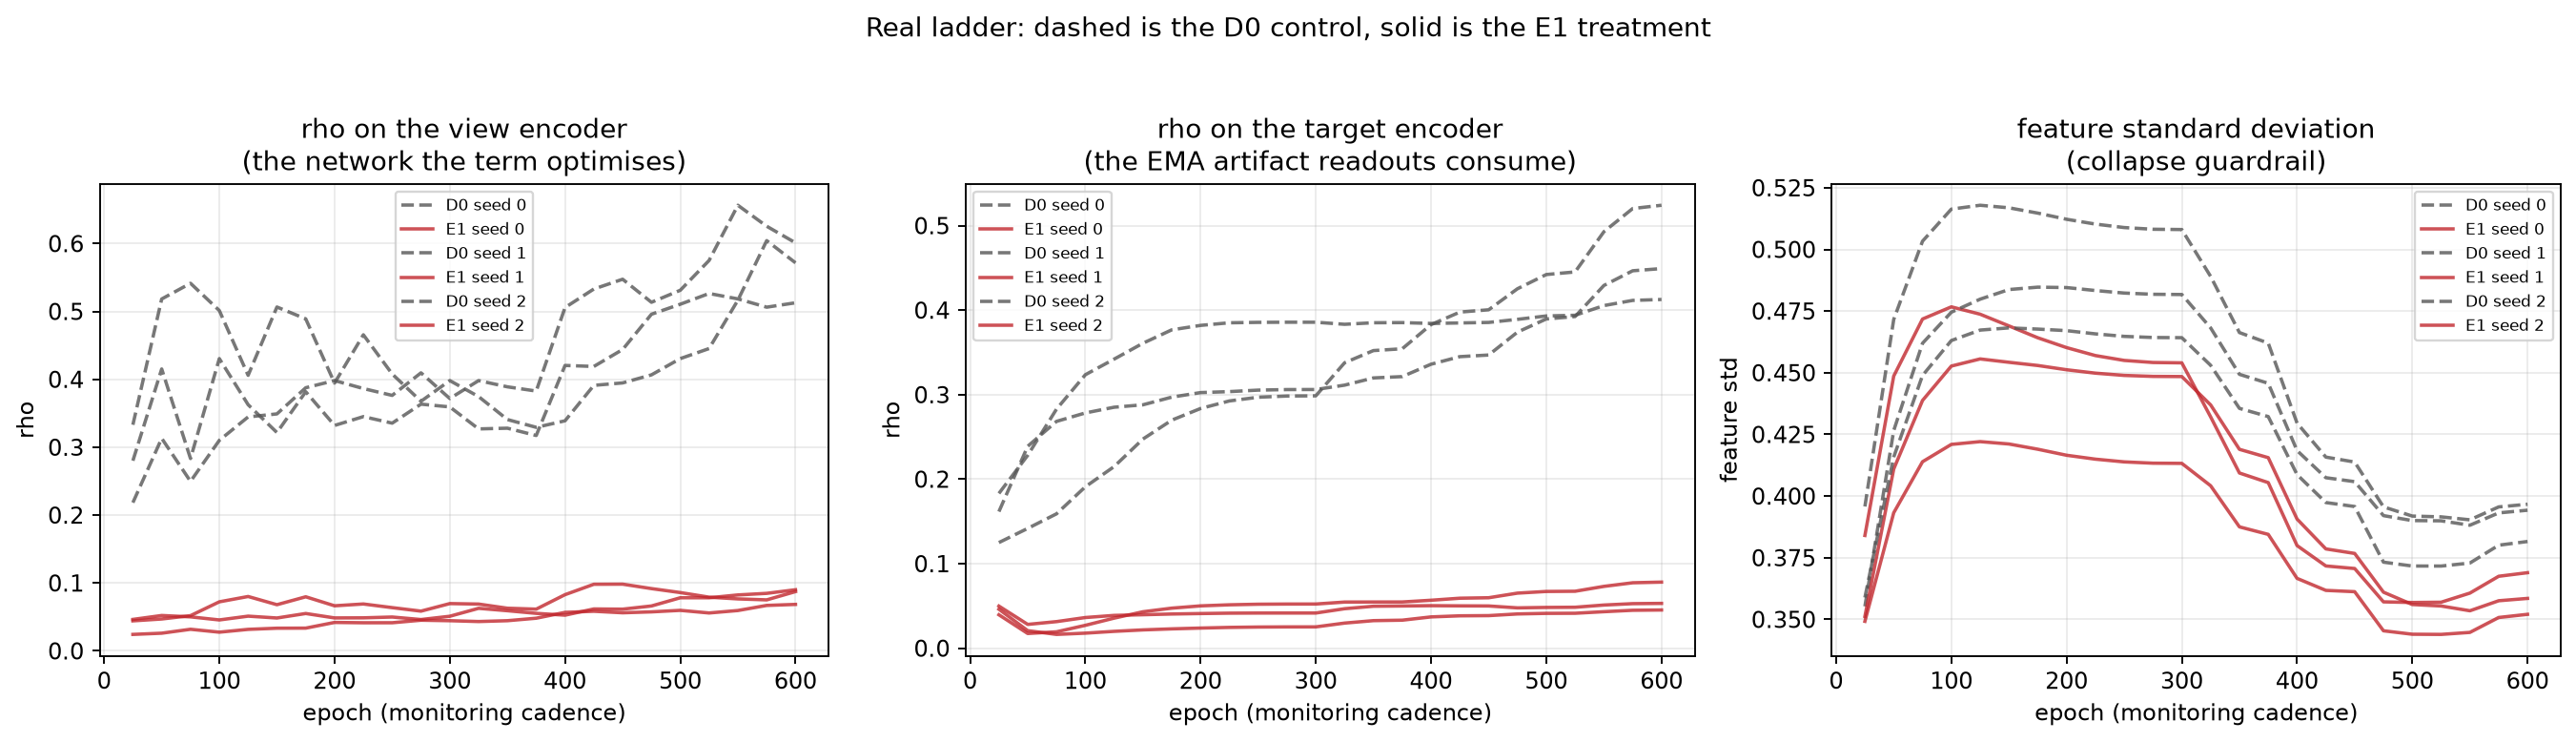

wrote /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/idea9_arm2/idea9_arm2_ladder_trajectories.png


In [6]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

figure, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for result in results:
    frame = pd.DataFrame(result["monitors"])
    updates = np.arange(1, len(frame) + 1) * MONITOR_EVERY
    colour = "#555555" if result["rung"] == "D0" else "#c1272d"
    style = "--" if result["rung"] == "D0" else "-"
    label = f"{result['rung']} seed {result['seed']}"
    axes[0].plot(updates, frame["rho_view"], style, color=colour, alpha=0.8, label=label)
    axes[1].plot(updates, frame["rho_target"], style, color=colour, alpha=0.8, label=label)
    axes[2].plot(updates, frame["feature_std"], style, color=colour, alpha=0.8, label=label)
axes[0].set_title("rho on the view encoder\n(the network the term optimises)")
axes[1].set_title("rho on the target encoder\n(the EMA artifact readouts consume)")
axes[2].set_title("feature standard deviation\n(collapse guardrail)")
for axis, ylabel in zip(axes, ["rho", "rho", "feature std"]):
    axis.set_xlabel("epoch (monitoring cadence)")
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.25)
    axis.legend(fontsize=7)
figure.suptitle("Real ladder: dashed is the D0 control, solid is the E1 treatment", y=1.03)
figure.tight_layout()
ladder_png = ARM2_DIR / "idea9_arm2_ladder_trajectories.png"
figure.savefig(ladder_png, dpi=170, bbox_inches="tight")
plt.close(figure)
display(Image(filename=str(ladder_png)))
print(f"wrote {ladder_png}")

## 5. What this notebook has produced, and what it deliberately has not

**Produced.** Two trained checkpoints per seed for seeds 0, 1 and 2, differing in exactly one term of the
objective, each with its own fingerprint, each with a recorded monitoring trajectory and a JSON summary,
plus a combined ladder bundle and a trajectory figure. That is the raw material for the comparison, and
nothing more than that.

**Observed, and reported without being judged.** The primary endpoint separates cleanly. Control rungs
finish between 0.41261 and 0.52410 on `rho_target`; treatment rungs finish between 0.04521 and 0.07820.
The head's output scale grows on average rather than shrinking, so the degenerate solution
`new_nb_09_01` found on fixtures does not obviously reproduce at real scale. Both statements are
observations about six trajectories. Neither is a verdict.

**Disclosed.** The ladder ran **3 seeds against 5 registered**, because measured per-rung cost on MPS
exceeded the estimate the wall-clock budget was approved against. `new_nb_09_03` records this as a formal
protocol deviation with its effect on inference.

**Deliberately not done: the judging.** No condition of the credit rule is applied here. rho is measured
during training as a monitor, but the scoring the rule refers to, including the source-grouped probes, the
guardrails, and the paired-by-source bootstrap, all happens in `new_nb_09_03` against the saved
checkpoints.

**Why the split is worth the inconvenience.** Two reasons, and the second is the important one.

The practical reason is auditability: because scoring reads only saved checkpoints, it can be rerun,
corrected, or independently checked by someone else without retraining anything.

The methodological reason is that a rule applied in the same notebook that produced the numbers is a rule
that can be adjusted while the numbers are visible, and it will be, in small and reasonable-feeling
increments. Having watched six trajectories separate this cleanly, it is genuinely tempting to decide that
a guardrail threshold was set too tight, or that one seed's control looks anomalous, or that a
not-evaluable guardrail can simply be dropped. Keeping the endpoint scoring in a separate notebook that
reads the contract file off disk puts all three of those moves out of reach. That protection is worth more
here than usual, because the verdict that is coming is a refusal, and a refusal is only credible if the
rule that produced it could not have been rewritten first.

**Next.** `new_nb_09_03` reloads these checkpoints, recomputes every endpoint with one instrument for
every rung, applies the three registered conditions in order, and issues the verdict.
